# PCB-MC Anomaly Detection Benchmark — 5-Fold Cross Validation

Two protocols × four methods × five folds = board-identity-aware AD evaluation
matching the detection benchmark.

| Protocol | Train (normal) | Test (abnormal) | Metric |
|---|---|---|---|
| **Full-image** | `non_missing/fold_k/train` images | `missing_only/fold_k/valid` images | Box-level mAP, F1, FNR |
| **Crop-level** | Present-component crops from `non_missing/fold_k/train` | Missing-component crops from `missing_only/fold_k/valid` | Crop-level AUROC, F1, FNR |

Results reported as **mean ± std** across 5 folds.

In [1]:
# Uncomment in a fresh Colab:
!pip install -q anomalib==1.2.0 lightning timm scikit-learn
!pip install -q opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.6/486.6 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.3/131.3 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 114.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 787.4/787.4 kB 104.4 MB/s eta 0:00:00


In [13]:
!pip uninstall -y pandas numpy opencv-python-headless
!pip install -q "numpy<2.0"
!pip install -q pandas
!pip install -q opencv-python-headless
!pip install -q anomalib==1.2.0 lightning timm scikit-learn imgaug

Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: opencv-python-headless 4.13.0.92
Uninstalling opencv-python-headless-4.13.0.92:
  Successfully uninstalled opencv-python-headless-4.13.0.92
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cufflinks 0.17.3 requires pandas>=0.19.2, which is not installed.
spaghetti 1.7.6 requires pandas!=1.5.0,>=1.4, which is not installed.
seaborn 0.13.2 requires pandas>=1.2, which is not installed.
gradio 5.50.0 requires pandas<3.0,>=1.0, which is not installed.
mlxtend 0.23.4 requires pandas>=0.24.2, which is not installed.
cmdstanpy 1.3.0 requires pandas, which is not installed.
pandas-gbq 0.30.0 requires pandas>=1.1.4, which is not 

In [3]:
!pip install anomalib

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 942.1/942.1 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.1/246.1 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 104.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 110.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 155.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 787.4/787.4 kB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 108.4 MB/s eta 0:00:00
  Created wheel for freia: filename=FrEIA-0.2-py3-none-any.whl size=42763 sha256=cde6613f44cb191f86584fe1e85e77c5c3aa91584f7fa6162aa72a9d0d954fa0
  Stored in d

In [4]:
import os, json, time, random, shutil, warnings, gc
from dataclasses import dataclass
from typing import List, Tuple, Dict, Callable, Optional
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt

import torch
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

warnings.filterwarnings("ignore")

# --- Fix PyTorch 2.6+ checkpoint loading with Anomalib ---
# Anomalib checkpoints contain custom enum types that torch.load
# rejects under weights_only=True (the new default in PyTorch 2.6).
# We allowlist them so load_from_checkpoint works.
try:
    import anomalib
    safe_types = []
    # Collect all enum/type objects Anomalib might serialize
    for attr_name in dir(anomalib):
        obj = getattr(anomalib, attr_name, None)
        if isinstance(obj, type):
            safe_types.append(obj)
    # Also get model-specific types
    try:
        from anomalib.models.image.reverse_distillation.anomaly_map import AnomalyMapGenerationMode
        safe_types.append(AnomalyMapGenerationMode)
    except ImportError:
        pass
    if safe_types:
        torch.serialization.add_safe_globals(safe_types)
        print(f"Registered {len(safe_types)} Anomalib safe globals for torch.load")
except Exception as e:
    print(f"Warning: could not register safe globals: {e}")

# --- GPU memory management ---
def clear_gpu():
    """Aggressively free GPU memory between runs."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

print(f"torch:           {torch.__version__}")
print(f"cuda available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"gpu:             {torch.cuda.get_device_name(0)}")
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"gpu memory:      {mem:.1f} GB")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)


Registered 5 Anomalib safe globals for torch.load
torch:           2.10.0+cu128
cuda available:  True
gpu:             NVIDIA RTX PRO 6000 Blackwell Server Edition
gpu memory:      102.0 GB


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# ============================================================
# Configuration
# ============================================================

ROOT = "/content/drive/MyDrive/PCB_MC/Data"
WORK_ROOT = "/content/pcbmc_anom_cv"
OUTPUT_DIR = "/content/drive/MyDrive/PCB_MC/AD_results"

N_FOLDS = 5

def fold_paths(fold_idx: int) -> dict:
    nm = os.path.join(ROOT, "non_missing", "kfold_data", f"fold_{fold_idx}")
    mo = os.path.join(ROOT, "missing_only", "kfold_data", f"fold_{fold_idx}")
    return {
        "nm_train_img": os.path.join(nm, "train", "images"),
        "nm_train_lab": os.path.join(nm, "train", "labels"),
        "nm_val_img":   os.path.join(nm, "valid", "images"),
        "nm_val_lab":   os.path.join(nm, "valid", "labels"),
        "mo_train_img": os.path.join(mo, "train", "images"),
        "mo_train_lab": os.path.join(mo, "train", "labels"),
        "mo_val_img":   os.path.join(mo, "valid", "images"),
        "mo_val_lab":   os.path.join(mo, "valid", "labels"),
    }

RUN = {
    "PatchCore":           True,
    "PaDiM":               True,
    "DRAEM":               True,
    "ReverseDistillation": True,
}

RUN_FULL_IMAGE = True
RUN_CROP_LEVEL = True

@dataclass
class Cfg:
    image_size: int = 256
    crop_size: int = 224
    context_factor: float = 1.4
    batch_size: int = 8
    num_workers: int = 2
    seed: int = SEED
    epochs_patchcore: int = 1
    epochs_padim: int = 1
    epochs_draem: int = 50
    epochs_rd: int = 50
    thr_quantile: float = 0.995
    min_box_area: int = 24
    # PatchCore memory bank limit: cap training crops to avoid OOM.
    # PatchCore stores embeddings for ALL training patches in GPU memory.
    # With 117k crops this exceeds even 96GB GPUs. 10k is sufficient for
    # a representative memory bank (PatchCore subsamples via coreset anyway).
    max_train_crops_patchcore: int = 10000

    smoke_test: bool = False

cfg = Cfg()

fp0 = fold_paths(0)
for key, p in fp0.items():
    assert os.path.exists(p), f"Fold 0 missing: {key} -> {p}"
print("Fold 0 paths validated.")

os.makedirs(WORK_ROOT, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Smoke test:  {cfg.smoke_test}")
print(f"Methods:     {[k for k,v in RUN.items() if v]}")
print(f"Experiments: full_image={RUN_FULL_IMAGE}, crop_level={RUN_CROP_LEVEL}")

Fold 0 paths validated.
Smoke test:  False
Methods:     ['PatchCore', 'PaDiM', 'DRAEM', 'ReverseDistillation']
Experiments: full_image=True, crop_level=True


In [6]:
# ============================================================
# Helpers
# ============================================================
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def list_images(folder):
    return sorted(os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(IMG_EXTS))

def label_path_from_image(image_path, labels_dir):
    return os.path.join(labels_dir, os.path.splitext(os.path.basename(image_path))[0] + ".txt")

def read_yolo_labels(label_path):
    if not os.path.exists(label_path): return []
    rows = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5: continue
            rows.append((int(float(parts[0])), *map(float, parts[1:5])))
    return rows

def yolo_to_xyxy(xc, yc, w, h, W, H):
    x1 = int(max(0, (xc - w/2) * W)); y1 = int(max(0, (yc - h/2) * H))
    x2 = int(min(W-1, (xc + w/2) * W)); y2 = int(min(H-1, (yc + h/2) * H))
    if x2 <= x1: x2 = min(W-1, x1+1)
    if y2 <= y1: y2 = min(H-1, y1+1)
    return x1, y1, x2, y2

def expand_box(x1, y1, x2, y2, W, H, factor=1.4):
    cx, cy = (x1+x2)/2, (y1+y2)/2
    bw, bh = (x2-x1)*factor, (y2-y1)*factor
    return int(max(0,cx-bw/2)), int(max(0,cy-bh/2)), int(min(W,cx+bw/2)), int(min(H,cy+bh/2))

def iou_xyxy(a, b):
    ix1,iy1 = max(a[0],b[0]), max(a[1],b[1])
    ix2,iy2 = min(a[2],b[2]), min(a[3],b[3])
    inter = max(0,ix2-ix1)*max(0,iy2-iy1)
    ua = max(0,a[2]-a[0])*max(0,a[3]-a[1])
    ub = max(0,b[2]-b[0])*max(0,b[3]-b[1])
    return float(inter/(ua+ub-inter+1e-9))

def nms(boxes, iou_thr=0.3):
    keep = []
    for b in sorted(boxes, key=lambda x: x[4], reverse=True):
        if all(iou_xyxy(b[:4], k[:4]) < iou_thr for k in keep):
            keep.append(b)
    return keep

def heatmap_to_boxes(heatmap, thr, min_area=24):
    mask = (heatmap.astype(np.float32) >= thr).astype(np.uint8)*255
    if mask.sum() == 0: return []
    k = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(cv2.morphologyEx(mask, cv2.MORPH_OPEN, k), cv2.MORPH_CLOSE, k)
    boxes = []
    for c in cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]:
        x,y,w,h = cv2.boundingRect(c)
        if w*h >= min_area:
            boxes.append((x,y,x+w,y+h, float(heatmap[y:y+h,x:x+w].mean())))
    return boxes

def compute_ap_11pt(scored_tp, total_gt):
    if total_gt == 0: return 0.0
    scored_tp = sorted(scored_tp, key=lambda x: x[0], reverse=True)
    tp = fp = 0; precs = []; recs = []
    for s, is_tp in scored_tp:
        tp += int(is_tp); fp += int(1-is_tp)
        precs.append(tp/max(1,tp+fp)); recs.append(tp/total_gt)
    return float(sum(max([p for p,r in zip(precs,recs) if r>=rt]+[0.0]) for rt in np.linspace(0,1,11))/11.0)

def get_gt_missing_boxes(img_path, labels_dir):
    labs = read_yolo_labels(label_path_from_image(img_path, labels_dir))
    W, H = Image.open(img_path).convert("RGB").size
    return [yolo_to_xyxy(xc,yc,w,h,W,H) for _,xc,yc,w,h in labs]

print("Helpers loaded.")

Helpers loaded.


In [7]:
# ============================================================
# Anomalib model registry
# ============================================================


from anomalib.data import Folder
from anomalib.engine import Engine
from anomalib.models import Patchcore, Padim

try:
    from anomalib.models import Draem
except ImportError:
    from anomalib.models.image.draem import Draem

try:
    from anomalib.models import ReverseDistillation
except ImportError:
    from anomalib.models.image.reverse_distillation import ReverseDistillation

def get_method(name):
    smoke = cfg.smoke_test
    reg = {
        "PatchCore":          (Patchcore,           cfg.epochs_patchcore),
        "PaDiM":              (Padim,               cfg.epochs_padim),
        "DRAEM":              (Draem,               cfg.epochs_draem if not smoke else 1),
        "ReverseDistillation":(ReverseDistillation, cfg.epochs_rd    if not smoke else 1),
    }
    cls, ep = reg[name]; return cls(), ep

def make_datamodule(root_dir):
    return Folder(name="PCB_MC_AD", root=root_dir,
                  normal_dir=os.path.join("train","normal"),
                  abnormal_dir=os.path.join("test","abnormal"),
                  train_batch_size=cfg.batch_size, eval_batch_size=cfg.batch_size,
                  num_workers=cfg.num_workers, seed=cfg.seed)

METHOD_NAMES = [n for n in RUN if RUN[n]]
METHOD_DISPLAY = {
    "PatchCore":           "PatchCore~\\cite{roth2022patchcore}",
    "PaDiM":               "PaDiM~\\cite{defard2021padim}",
    "DRAEM":               "DRAEM~\\cite{zavrtanik2021draemdiscriminativelytrained}",
    "ReverseDistillation": "Rev.\\ Distill.~\\cite{deng2022reverse}",
}
print("Methods:", METHOD_NAMES)


Methods: ['PatchCore', 'PaDiM', 'DRAEM', 'ReverseDistillation']


In [8]:
# ============================================================
# Per-fold data preparation
# ============================================================
def symlink_many(src_paths, dst_dir):
    os.makedirs(dst_dir, exist_ok=True)
    for src in src_paths:
        dst = os.path.join(dst_dir, os.path.basename(src))
        if not os.path.exists(dst): os.symlink(src, dst)

def prepare_fullimage_folder(fold_idx):
    fp = fold_paths(fold_idx)
    root = os.path.join(WORK_ROOT, f"fold_{fold_idx}", "fullimg")
    if os.path.exists(root): shutil.rmtree(root)
    train = list_images(fp["nm_train_img"])
    val   = list_images(fp["nm_val_img"])
    test  = list_images(fp["mo_val_img"])
    if cfg.smoke_test: train=train[:20]; val=val[:10]; test=test[:10]
    symlink_many(train, os.path.join(root,"train","normal"))
    symlink_many(val,   os.path.join(root,"test","normal"))
    symlink_many(test,  os.path.join(root,"test","abnormal"))
    return root

def extract_crops(image_dir, labels_dir, output_dir, context_factor=1.4, max_crops=None):
    os.makedirs(output_dir, exist_ok=True)
    count = 0
    for img_path in list_images(image_dir):
        labels = read_yolo_labels(label_path_from_image(img_path, labels_dir))
        if not labels: continue
        img = cv2.imread(img_path)
        if img is None: continue
        H, W = img.shape[:2]
        stem = os.path.splitext(os.path.basename(img_path))[0]
        for i, (cls, xc, yc, w, h) in enumerate(labels):
            x1,y1,x2,y2 = yolo_to_xyxy(xc,yc,w,h,W,H)
            x1e,y1e,x2e,y2e = expand_box(x1,y1,x2,y2,W,H,context_factor)
            crop = img[y1e:y2e, x1e:x2e]
            if crop.size == 0: continue
            cv2.imwrite(os.path.join(output_dir, f"{stem}_c{i:04d}.png"), crop)
            count += 1
            if max_crops and count >= max_crops: return count
    return count

def prepare_crop_folder(fold_idx):
    fp = fold_paths(fold_idx)
    root = os.path.join(WORK_ROOT, f"fold_{fold_idx}", "crops")
    if os.path.exists(root): shutil.rmtree(root)
    max_c = 500 if cfg.smoke_test else None

    n_train = extract_crops(fp["nm_train_img"], fp["nm_train_lab"],
                            os.path.join(root,"train","normal"), cfg.context_factor, max_c)
    # Count for reporting; actual subsampling for PatchCore happens at train time
    val_normal_dir = os.path.join(root, "val_normal_raw")
    n_val = extract_crops(fp["nm_val_img"], fp["nm_val_lab"],
                          val_normal_dir, cfg.context_factor, max_c)
    test_normal = os.path.join(root,"test","normal")
    os.makedirs(test_normal, exist_ok=True)
    for f in os.listdir(val_normal_dir):
        src = os.path.join(val_normal_dir, f)
        dst = os.path.join(test_normal, f)
        if not os.path.exists(dst): os.symlink(src, dst)
    n_anom = extract_crops(fp["mo_val_img"], fp["mo_val_lab"],
                           os.path.join(root,"test","abnormal"), cfg.context_factor, max_c)
    print(f"  Fold {fold_idx} crops: {n_train} train, {n_val} val-normal, {n_anom} test-anomaly")
    return root, val_normal_dir

print("Data preparation functions loaded.")

Data preparation functions loaded.


In [9]:
# ============================================================
# Training and inference (with memory management + checkpoint fix)
# ============================================================

def train_method(name, data_root, run_dir):
    clear_gpu()  # Free memory before each training run
    model, max_epochs = get_method(name)
    os.makedirs(run_dir, exist_ok=True)

    # For PatchCore on crop-level: subsample training images to avoid OOM
    # when building the memory bank. We create a temp dir with symlinks.
    actual_root = data_root
    if name == "PatchCore":
        train_dir = os.path.join(data_root, "train", "normal")
        if os.path.exists(train_dir):
            all_imgs = sorted([f for f in os.listdir(train_dir) if f.lower().endswith(IMG_EXTS)])
            if len(all_imgs) > cfg.max_train_crops_patchcore:
                print(f"  PatchCore: subsampling {len(all_imgs)} -> {cfg.max_train_crops_patchcore} train crops")
                sub_root = os.path.join(run_dir, "_subsampled")
                sub_train = os.path.join(sub_root, "train", "normal")
                if os.path.exists(sub_root): shutil.rmtree(sub_root)
                os.makedirs(sub_train, exist_ok=True)
                # Copy test dirs via symlink
                test_dir = os.path.join(data_root, "test")
                sub_test = os.path.join(sub_root, "test")
                if os.path.exists(test_dir):
                    if os.path.exists(sub_test): shutil.rmtree(sub_test)
                    os.symlink(os.path.abspath(test_dir), sub_test)
                # Subsample training
                rng = random.Random(SEED + 99)
                sampled = rng.sample(all_imgs, cfg.max_train_crops_patchcore)
                for f in sampled:
                    src = os.path.join(train_dir, f)
                    dst = os.path.join(sub_train, f)
                    if not os.path.exists(dst): os.symlink(os.path.abspath(src), dst)
                actual_root = sub_root

    engine = Engine(default_root_dir=run_dir,
                    accelerator="gpu" if DEVICE=="cuda" else "cpu",
                    devices=1, max_epochs=max_epochs, enable_progress_bar=False)
    t0 = time.time()
    engine.fit(model=model, datamodule=make_datamodule(actual_root))
    elapsed = time.time() - t0

    ckpt = None
    if engine.checkpoint_callback is not None:
        ckpt = engine.checkpoint_callback.best_model_path
    if not ckpt or not os.path.exists(str(ckpt)):
        for p in Path(run_dir).rglob("*.ckpt"):
            ckpt = str(p); break

    # Free the training model from GPU
    del model, engine
    clear_gpu()

    return str(ckpt) if ckpt else "", elapsed


class SimpleImageDataset(Dataset):
    def __init__(self, paths, image_size):
        self.paths = paths
        self.tf = T.Compose([T.Resize((image_size,image_size)), T.ToTensor()])
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        p = self.paths[idx]
        return {"path": p, "image": self.tf(Image.open(p).convert("RGB"))}

def _extract_amap_score(pred):
    if isinstance(pred, dict):
        amap = pred.get("anomaly_map", pred.get("anomaly_maps"))
        score = pred.get("pred_score", pred.get("pred_scores"))
    else:
        amap = getattr(pred,"anomaly_map",getattr(pred,"anomaly_maps",None))
        score = getattr(pred,"pred_score",getattr(pred,"pred_scores",None))
    return amap, score

@torch.no_grad()
def predict_anomaly_maps(method_name, ckpt_path, image_paths, image_size):
    clear_gpu()
    model_cls = get_method(method_name)[0].__class__

    # Fix for PyTorch 2.6+: force weights_only=False if safe_globals didn't work
    try:
        model = model_cls.load_from_checkpoint(ckpt_path)
    except Exception:
        # Fallback: load with weights_only=False
        ckpt_data = torch.load(ckpt_path, map_location="cpu", weights_only=False)
        model = model_cls()
        if "state_dict" in ckpt_data:
            model.load_state_dict(ckpt_data["state_dict"], strict=False)
        else:
            model.load_state_dict(ckpt_data, strict=False)

    model.eval().to(DEVICE)

    ds = SimpleImageDataset(image_paths, image_size)
    dl = DataLoader(ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)
    out = {}
    for batch in dl:
        x = batch["image"].to(DEVICE); paths = batch["path"]
        pred = model(x); amap, score = _extract_amap_score(pred)
        if amap is not None and amap.ndim == 4: amap = amap[:,0]
        if score is None and amap is not None: score = amap.flatten(1).max(dim=1).values
        amap_np = amap.detach().cpu().numpy() if amap is not None else np.zeros((len(paths),image_size,image_size))
        score_np = score.detach().cpu().numpy() if score is not None else np.zeros(len(paths))
        for i, p in enumerate(paths):
            W, H = Image.open(p).convert("RGB").size
            out[p] = (W, H, amap_np[i].astype(np.float32), float(score_np[i]))

    del model
    clear_gpu()
    return out

def estimate_thr_from_normals(results_normal, q):
    vals = []
    for (_,_,amap,_) in results_normal.values():
        flat = amap.reshape(-1)
        if flat.size > 20000: flat = np.random.choice(flat, 20000, replace=False)
        vals.append(flat)
    return float(np.quantile(np.concatenate(vals), q)) if vals else 0.0

print("Training/inference loaded (with OOM fixes).")


Training/inference loaded (with OOM fixes).


In [10]:
# ============================================================
# Evaluation functions
# ============================================================
def eval_fullimage(results_test, test_img_paths, labels_dir, thr):
    total_gt=tp=fp=matched_gt=0; scored_tp=[]
    for img_path in test_img_paths:
        if img_path not in results_test: continue
        W,H,amap,_ = results_test[img_path]
        Ha,Wa = amap.shape; sx,sy = W/Wa, H/Ha
        preds = [(int(x1*sx),int(y1*sy),int(x2*sx),int(y2*sy),s)
                 for x1,y1,x2,y2,s in heatmap_to_boxes(amap,thr,cfg.min_box_area)]
        preds = nms(preds, 0.3)
        gt = get_gt_missing_boxes(img_path, labels_dir); total_gt += len(gt)
        gt_used = [False]*len(gt)
        for x1,y1,x2,y2,score in preds:
            bi,biou = -1,0.0
            for i,g in enumerate(gt):
                if gt_used[i]: continue
                v = iou_xyxy((x1,y1,x2,y2),g)
                if v > biou: bi,biou = i,v
            if bi>=0 and biou>=0.5:
                gt_used[bi]=True; tp+=1; scored_tp.append((score,1))
            else: fp+=1; scored_tp.append((score,0))
        matched_gt += sum(gt_used)
    prec = tp/max(1,tp+fp); rec = matched_gt/max(1,total_gt)
    f1 = (2*prec*rec)/max(1e-9,prec+rec)
    return {"mAP": round(compute_ap_11pt(scored_tp,total_gt),4),
            "f1": round(f1,4), "fnr": round(1-rec,4)}

def eval_crop_level(method_name, ckpt_path, val_normal_dir, test_anomaly_dir):
    normal_paths = sorted([os.path.join(val_normal_dir,f)
                           for f in os.listdir(val_normal_dir) if f.lower().endswith(IMG_EXTS)])
    anomaly_paths = sorted([os.path.join(test_anomaly_dir,f)
                            for f in os.listdir(test_anomaly_dir) if f.lower().endswith(IMG_EXTS)])
    if cfg.smoke_test: normal_paths=normal_paths[:200]; anomaly_paths=anomaly_paths[:200]
    print(f"  Crop eval: {len(normal_paths)} normal, {len(anomaly_paths)} anomaly")

    all_paths = normal_paths + anomaly_paths
    labels = np.array([0]*len(normal_paths) + [1]*len(anomaly_paths))
    results = predict_anomaly_maps(method_name, ckpt_path, all_paths, cfg.crop_size)
    scores = np.array([results[p][3] for p in all_paths if p in results])
    vlabels = np.array([l for p,l in zip(all_paths,labels) if p in results])

    auroc = roc_auc_score(vlabels, scores) if len(np.unique(vlabels))>=2 else 0.0
    best_f1, best_thr = 0.0, 0.0
    for q in np.linspace(0.01, 0.99, 200):
        thr = np.quantile(scores, q)
        f = f1_score(vlabels, (scores>=thr).astype(int), zero_division=0)
        if f > best_f1: best_f1, best_thr = f, thr
    rec = recall_score(vlabels, (scores>=best_thr).astype(int), zero_division=0)
    return {"AUROC": round(float(auroc),4), "f1": round(float(best_f1),4),
            "fnr": round(float(1-rec),4), "n_normal": int(sum(vlabels==0)),
            "n_anomaly": int(sum(vlabels==1))}

print("Evaluation functions loaded.")

Evaluation functions loaded.


In [11]:
# ============================================================
# EXPERIMENT 1: Full-image AD (5-fold)
# ============================================================
fullimg_per_fold = {n: [] for n in METHOD_NAMES}
fullimg_heatmaps_fold0 = {}

if RUN_FULL_IMAGE:
    print("=" * 60)
    print("EXPERIMENT 1: FULL-IMAGE AD (5-fold)")
    print("=" * 60)
    for fold_idx in range(N_FOLDS):
        clear_gpu()
        print(f"\n{'='*40} FOLD {fold_idx} {'='*40}")
        fp = fold_paths(fold_idx)
        fi_root = prepare_fullimage_folder(fold_idx)
        val_paths = list_images(fp["nm_val_img"])
        test_paths = list_images(fp["mo_val_img"])
        if cfg.smoke_test: val_paths=val_paths[:10]; test_paths=test_paths[:10]

        for name in METHOD_NAMES:
            try:
                run_dir = os.path.join(WORK_ROOT, f"fold_{fold_idx}", f"fi_{name.lower()}")
                ckpt, t = train_method(name, fi_root, run_dir)
                print(f"  {name}: {t:.1f}s")
                val_pred = predict_anomaly_maps(name, ckpt, val_paths, cfg.image_size)
                thr = estimate_thr_from_normals(val_pred, cfg.thr_quantile)
                test_pred = predict_anomaly_maps(name, ckpt, test_paths, cfg.image_size)
                if fold_idx == 0: fullimg_heatmaps_fold0[name] = test_pred
                metrics = eval_fullimage(test_pred, test_paths, fp["mo_val_lab"], thr)
                metrics["fold"] = fold_idx; metrics["train_s"] = round(t,1)
                fullimg_per_fold[name].append(metrics)
                print(f"    mAP={metrics['mAP']} F1={metrics['f1']} FNR={metrics['fnr']}")
            except Exception as e:
                print(f"    [ERROR] {name}: {e}")
                import traceback; traceback.print_exc()
else:
    print("Full-image SKIPPED.")

EXPERIMENT 1: FULL-IMAGE AD (5-fold)

======================================== FOLD 0 ========================================


model.safetensors:   0%|          | 0.00/276M [00:00<?, ?B/s]

INFO:lightning_fabric.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:lightning_fabric.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:lightning_fabric.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning_fabric.utilities.rank_zero:You are using a CUDA device ('NVIDIA RTX PRO 6000 Blackwell Server Edition') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor   │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor  │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator      │      0 │ train │     0 │
│ 3 │ model          │ PatchcoreModel │ 24.9 M │ train │     0 │
└───┴────────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 24.9 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.9 M                                                                                               
Total estimated model params size (MB): 99                                                                         
Modules in train mode: 19                                                                                          
Modules in eval mode: 174                                                                                          
Total FLOPs: 0

...

INFO:lightning_fabric.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:lightning_fabric.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:lightning_fabric.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor             │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor            │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator                │      0 │ train │     0 │
│ 3 │ model          │ ReverseDistillationModel │ 89.0 M │ train │     0 │
│ 4 │ loss           │ ReverseDistillationLoss  │      0 │ train │     0 │
└───┴────────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 89.0 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 89.0 M                                                                                               
Total estimated model params size (MB): 356                                                                        
Modules in train mode: 347                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO:lightning_fabric.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


  ReverseDistillation: 338.2s
    mAP=0.0 F1=0.0 FNR=1.0


In [12]:
# ============================================================
# EXPERIMENT 2: Crop-level AD (5-fold)
# ============================================================
crop_per_fold = {n: [] for n in METHOD_NAMES}

if RUN_CROP_LEVEL:
    print("=" * 60)
    print("EXPERIMENT 2: CROP-LEVEL AD (5-fold)")
    print("=" * 60)
    for fold_idx in range(N_FOLDS):
        clear_gpu()
        print(f"\n{'='*40} FOLD {fold_idx} {'='*40}")
        crop_root, val_normal_dir = prepare_crop_folder(fold_idx)
        test_anomaly_dir = os.path.join(crop_root, "test", "abnormal")

        for name in METHOD_NAMES:
            try:
                run_dir = os.path.join(WORK_ROOT, f"fold_{fold_idx}", f"cr_{name.lower()}")
                ckpt, t = train_method(name, crop_root, run_dir)
                print(f"  {name}: {t:.1f}s")
                metrics = eval_crop_level(name, ckpt, val_normal_dir, test_anomaly_dir)
                metrics["fold"] = fold_idx; metrics["train_s"] = round(t,1)
                crop_per_fold[name].append(metrics)
                print(f"    AUROC={metrics['AUROC']} F1={metrics['f1']} FNR={metrics['fnr']}")
            except Exception as e:
                print(f"    [ERROR] {name}: {e}")
                import traceback; traceback.print_exc()
else:
    print("Crop-level SKIPPED.")

EXPERIMENT 2: CROP-LEVEL AD (5-fold)

======================================== FOLD 0 ========================================
  Fold 0 crops: 49415 train, 9360 val-normal, 1394 test-anomaly


INFO:lightning_fabric.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:lightning_fabric.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:lightning_fabric.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


  PatchCore: subsampling 49415 -> 10000 train crops


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor   │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor  │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator      │      0 │ train │     0 │
│ 3 │ model          │ PatchcoreModel │ 24.9 M │ train │     0 │
└───┴────────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 24.9 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.9 M                                                                                               
Total estimated model params size (MB): 99                                                                         
Modules in train mode: 19                                                                                          
Modules in eval mode: 174                                                                                          
Total FLOPs: 0

Selecting Coreset Indices.:  11%|█         | 90492/819199 [39:35<5:18:48, 38.09it/s]
INFO:lightning_fabric.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/call.py", line 49, in _call_and_handle_interrupt
    return trainer_fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/trainer.py", line 630, in _fit_impl
    self._run(model, ckpt_path=ckpt_path, weights_only=weights_only)
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/trainer.py", line 1079, in _run
    results = self._run_stage()
              ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/trainer.py", line 1123, in _run_stage
    self.fit_loop.run()
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py", line 217, in run
    self.advance()
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py", line 465, in advance
    self.epoch_loop.run(self._data_fetcher)
  File

TypeError: object of type 'NoneType' has no len()

In [13]:
# ============================================================
# Aggregate + LaTeX + save
# ============================================================
def aggregate(per_fold, keys):
    rows = []
    for name, folds in per_fold.items():
        if not folds: continue
        row = {"Method": name}
        for k in keys:
            vals = [r[k] for r in folds if k in r]
            row[f"{k}_mean"] = np.mean(vals) if vals else 0.0
            row[f"{k}_std"]  = np.std(vals)  if vals else 0.0
        rows.append(row)
    return pd.DataFrame(rows)

def fmt_ms(m, s): return f"{m:.2f} \u00b1 {s:.2f}"
def fmt_si(m, s): return f"{m:.2f}({int(s*100):02d})"

df_fi = aggregate(fullimg_per_fold, ["mAP","f1","fnr"])
df_cr = aggregate(crop_per_fold, ["AUROC","f1","fnr"])

if not df_fi.empty:
    print("\n=== FULL-IMAGE AD (mean \u00b1 std) ===")
    for _,r in df_fi.iterrows():
        print(f"  {r['Method']:22s}  mAP={fmt_ms(r['mAP_mean'],r['mAP_std'])}  "
              f"F1={fmt_ms(r['f1_mean'],r['f1_std'])}  FNR={fmt_ms(r['fnr_mean'],r['fnr_std'])}")

if not df_cr.empty:
    print("\n=== CROP-LEVEL AD (mean \u00b1 std) ===")
    for _,r in df_cr.iterrows():
        print(f"  {r['Method']:22s}  AUROC={fmt_ms(r['AUROC_mean'],r['AUROC_std'])}  "
              f"F1={fmt_ms(r['f1_mean'],r['f1_std'])}  FNR={fmt_ms(r['fnr_mean'],r['fnr_std'])}")

# --- LaTeX ---
L = []
if not df_fi.empty:
    L.append("% === Full-image AD rows for Table III (PCB-MC-M) ===")
    L.append("\\midrule")
    L.append("\\multicolumn{5}{l}{\\textit{Anomaly Detection -- full-image (unsupervised)}} \\\\")
    L.append("\\midrule")
    for _,r in df_fi.iterrows():
        d = METHOD_DISPLAY.get(r["Method"], r["Method"])
        L.append(f"{d} & PCB-MC-M & {fmt_si(r['mAP_mean'],r['mAP_std'])} & "
                 f"{fmt_si(r['f1_mean'],r['f1_std'])} & {fmt_si(r['fnr_mean'],r['fnr_std'])} \\\\")

if not df_cr.empty:
    L.append("")
    L.append("% === Crop-level AD table (standalone) ===")
    L.append("\\begin{table}[t]")
    L.append("\\caption{Crop-level anomaly detection on component patches")
    L.append("($1.4\\times$ context). Mean $\\pm$ std across 5 folds.}")
    L.append("\\label{tab:ad_crop}")
    L.append("\\centering\\small")
    L.append("\\begin{tabular}{l S[table-format=1.2(2)] S[table-format=1.2(2)] S[table-format=1.2(2)]}")
    L.append("\\toprule")
    L.append("Method & {AUROC} & {F1} & {FNR} \\\\")
    L.append("\\midrule")
    for _,r in df_cr.iterrows():
        d = METHOD_DISPLAY.get(r["Method"], r["Method"])
        L.append(f"{d} & {fmt_si(r['AUROC_mean'],r['AUROC_std'])} & "
                 f"{fmt_si(r['f1_mean'],r['f1_std'])} & {fmt_si(r['fnr_mean'],r['fnr_std'])} \\\\")
    L.append("\\bottomrule")
    L.append("\\end{tabular}")
    L.append("\\end{table}")

latex = "\n".join(L)
out_tex = os.path.join(OUTPUT_DIR, "results_ad_5fold.tex")
with open(out_tex, "w") as f: f.write(latex)
print("\n=== LaTeX ==="); print(latex); print(f"\nSaved: {out_tex}")

all_res = {"full_image": {n:f for n,f in fullimg_per_fold.items() if f},
           "crop_level": {n:f for n,f in crop_per_fold.items() if f}}
out_json = os.path.join(OUTPUT_DIR, "results_ad_5fold.json")
with open(out_json, "w") as f: json.dump(all_res, f, indent=2)
print(f"Saved: {out_json}")


=== FULL-IMAGE AD (mean ± std) ===
  PatchCore               mAP=0.00 ± 0.00  F1=0.00 ± 0.00  FNR=1.00 ± 0.00
  PaDiM                   mAP=0.00 ± 0.00  F1=0.00 ± 0.00  FNR=1.00 ± 0.00
  DRAEM                   mAP=0.00 ± 0.00  F1=0.00 ± 0.00  FNR=1.00 ± 0.00
  ReverseDistillation     mAP=0.00 ± 0.00  F1=0.00 ± 0.00  FNR=1.00 ± 0.00

=== LaTeX ===
% === Full-image AD rows for Table III (PCB-MC-M) ===
\midrule
\multicolumn{5}{l}{\textit{Anomaly Detection -- full-image (unsupervised)}} \\
\midrule
PatchCore~\cite{roth2022patchcore} & PCB-MC-M & 0.00(00) & 0.00(00) & 1.00(00) \\
PaDiM~\cite{defard2021padim} & PCB-MC-M & 0.00(00) & 0.00(00) & 1.00(00) \\
DRAEM~\cite{zavrtanik2021draemdiscriminativelytrained} & PCB-MC-M & 0.00(00) & 0.00(00) & 1.00(00) \\
Rev.\ Distill.~\cite{deng2022reverse} & PCB-MC-M & 0.00(00) & 0.00(00) & 1.00(00) \\

Saved: /content/drive/MyDrive/PCB_MC/AD_results/results_ad_5fold.tex
Saved: /content/drive/MyDrive/PCB_MC/AD_results/results_ad_5fold.json


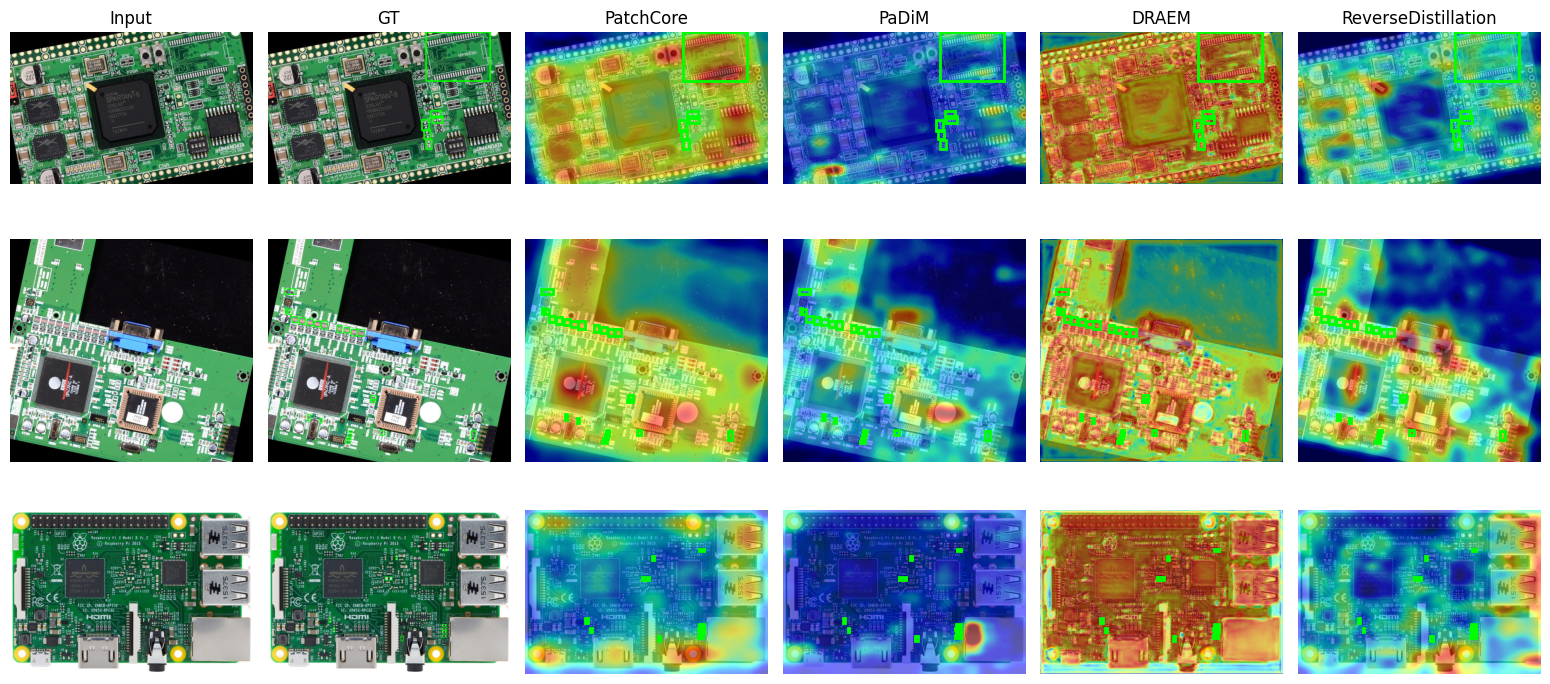

Saved: /content/drive/MyDrive/PCB_MC/AD_results/qualitative_fullimage_5fold.pdf


In [14]:
# ============================================================
# Qualitative: full-image heatmaps (fold 0)
# ============================================================
def normalize_heatmap(a):
    a = a - a.min()
    return a/a.max() if a.max()>0 else a

fp0 = fold_paths(0)
if fullimg_heatmaps_fold0:
    test_f0 = list_images(fp0["mo_val_img"])
    cands = [p for p in test_f0
             if len(get_gt_missing_boxes(p, fp0["mo_val_lab"]))>0
             and all(p in fullimg_heatmaps_fold0[m] for m in fullimg_heatmaps_fold0)]
    random.seed(7); random.shuffle(cands); demo = cands[:3]
    if demo:
        methods = list(fullimg_heatmaps_fold0.keys())
        nr, nc = len(demo), 2+len(methods)
        fig, axes = plt.subplots(nr, nc, figsize=(2.6*nc, 2.6*nr))
        if nr==1: axes=axes[None,:]
        for r, ip in enumerate(demo):
            img = np.array(Image.open(ip).convert("RGB"))
            gt = get_gt_missing_boxes(ip, fp0["mo_val_lab"])
            axes[r,0].imshow(img); axes[r,0].set_title("Input" if r==0 else ""); axes[r,0].axis("off")
            vis=img.copy()
            for x1,y1,x2,y2 in gt: cv2.rectangle(vis,(x1,y1),(x2,y2),(0,255,0),3)
            axes[r,1].imshow(vis); axes[r,1].set_title("GT" if r==0 else ""); axes[r,1].axis("off")
            for j,m in enumerate(methods):
                W,H,am,_ = fullimg_heatmaps_fold0[m][ip]
                amr = cv2.resize(am,(img.shape[1],img.shape[0]),interpolation=cv2.INTER_LINEAR)
                ax=axes[r,2+j]; ax.imshow(img); ax.imshow(normalize_heatmap(amr),cmap="jet",alpha=0.55)
                for x1,y1,x2,y2 in gt:
                    ax.add_patch(plt.Rectangle((x1,y1),x2-x1,y2-y1,fill=False,edgecolor="lime",lw=2))
                ax.set_title(m if r==0 else ""); ax.axis("off")
        plt.tight_layout()
        out_pdf = os.path.join(OUTPUT_DIR, "qualitative_fullimage_5fold.pdf")
        plt.savefig(out_pdf,dpi=200,bbox_inches="tight")
        plt.savefig(out_pdf.replace(".pdf",".png"),dpi=200,bbox_inches="tight")
        plt.show(); print(f"Saved: {out_pdf}")
else:
    print("No heatmaps cached.")

In [15]:
# ============================================================
# Score distribution plot (crop-level, fold 0)
# ============================================================
if crop_per_fold and any(crop_per_fold.values()):
    crop_root_f0 = os.path.join(WORK_ROOT, "fold_0", "crops")
    vnf0 = os.path.join(crop_root_f0, "val_normal_raw")
    taf0 = os.path.join(crop_root_f0, "test", "abnormal")
    if os.path.exists(vnf0) and os.path.exists(taf0):
        np_ = sorted([os.path.join(vnf0,f) for f in os.listdir(vnf0) if f.lower().endswith(IMG_EXTS)])
        ap_ = sorted([os.path.join(taf0,f) for f in os.listdir(taf0) if f.lower().endswith(IMG_EXTS)])
        ma = [n for n in METHOD_NAMES if list(Path(os.path.join(WORK_ROOT,"fold_0",f"cr_{n.lower()}")).rglob("*.ckpt"))]
        if ma:
            fig,axes = plt.subplots(1,len(ma),figsize=(4.5*len(ma),3.5))
            if len(ma)==1: axes=[axes]
            for ax,name in zip(axes,ma):
                ckpt = str(list(Path(os.path.join(WORK_ROOT,"fold_0",f"cr_{name.lower()}")).rglob("*.ckpt"))[0])
                preds = predict_anomaly_maps(name, ckpt, np_+ap_, cfg.crop_size)
                sn=[preds[p][3] for p in np_ if p in preds]
                sa=[preds[p][3] for p in ap_ if p in preds]
                ax.hist(sn,bins=50,alpha=0.6,label="Normal (present)",color="steelblue",density=True)
                ax.hist(sa,bins=50,alpha=0.6,label="Anomaly (missing)",color="coral",density=True)
                ax.set_title(name,fontsize=10); ax.set_xlabel("Anomaly score"); ax.legend(fontsize=8)
            plt.suptitle("Score distributions: Normal vs Missing crops (fold 0)",fontsize=11)
            plt.tight_layout()
            out_pdf = os.path.join(OUTPUT_DIR,"score_distributions_5fold.pdf")
            plt.savefig(out_pdf,dpi=200,bbox_inches="tight")
            plt.savefig(out_pdf.replace(".pdf",".png"),dpi=200,bbox_inches="tight")
            plt.show(); print(f"Saved: {out_pdf}")
else:
    print("No crop data.")

No crop data.


## Summary

### Output files
| File | Content |
|---|---|
| `results_ad_5fold.json` | All per-fold metrics (both experiments) |
| `results_ad_5fold.tex` | LaTeX: full-image rows + crop-level table |
| `qualitative_fullimage_5fold.pdf` | Heatmap figure (fold 0) |
| `score_distributions_5fold.pdf` | Normal vs anomaly score histograms |

### Expected narrative

| | Full-image | Crop-level |
|---|---|---|
| **Controls for layout?** | No | Yes |
| **Expected** | mAP ≈ 0, FNR = 1.0 | AUROC higher if absence is detectable |
| **Proves** | Layout variation overwhelms footprint signal | Whether absence is discriminable given localization |

Both experiments now use **board-identity-aware 5-fold CV**, matching all detection results in the paper.